# Door Open Variation Plots

This notebook generates time-series plots for room temperature, system COP, and refrigerant mass flow rate for each door-open duration case.

In [3]:
# Import required libraries
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Locate output files when running from either project root or visualization folder
project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs"

# Door-open simulation cases
door_cases = {
    "Door open 30 s": output_dir / "paper_reference_case_door_30s.csv",
    "Door open 60 s": output_dir / "paper_reference_case_door_60s.csv",
    "Door open 120 s": output_dir / "paper_reference_case_door_120s.csv",
}

# Consistent academic plot style
plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 1.0,
    "figure.dpi": 120,
})

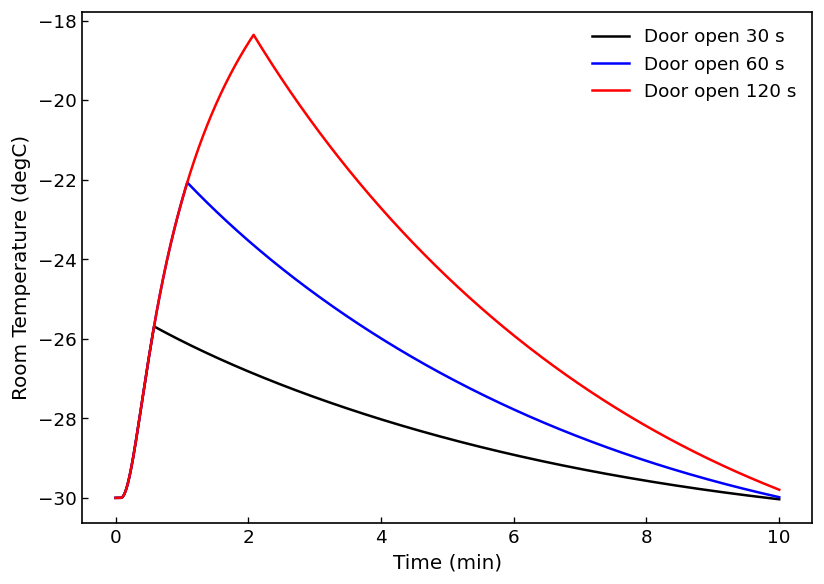

In [4]:
# Plot room temperature over time
plt.figure(figsize=(7, 5))

# Define distinct colors for each door-open duration
colors = ["black", "blue", "red"]

for i, (case_name, file_path) in enumerate(door_cases.items()):
    df = pd.read_csv(file_path)

    # Keep time and room temperature columns
    df = df[["time_s", "room_c"]]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()

    time_min = df["time_s"] / 60
    room_temp = df["room_c"]

    plt.plot(time_min, room_temp, linewidth=1.5, color=colors[i], label=case_name)

# Academic-style formatting
plt.xlabel("Time (min)", fontsize=12)
plt.ylabel("Room Temperature (degC)", fontsize=12)
plt.legend(frameon=False)
plt.tick_params(direction="in")
plt.tight_layout()

plt.show()

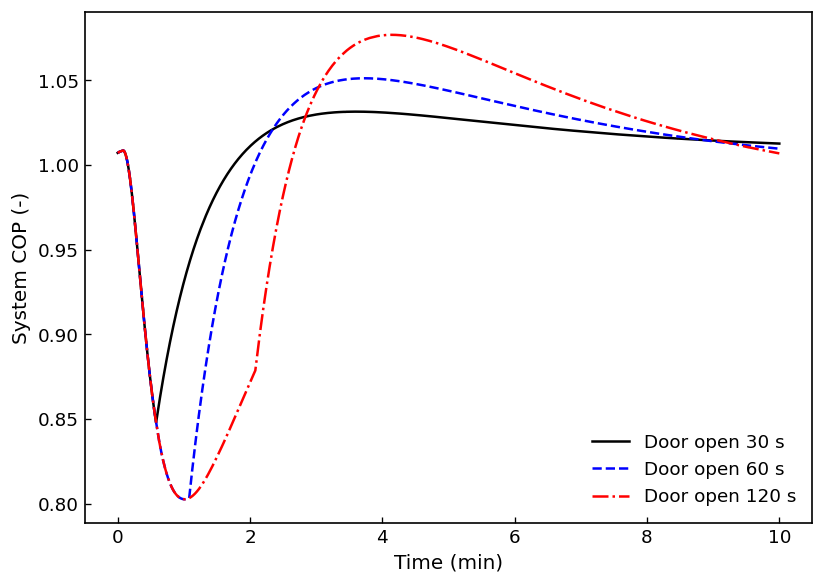

In [5]:
# Plot coefficient of performance over time
plt.figure(figsize=(7, 5))

# Use line styles to separate the same door-open cases
line_styles = ["-", "--", "-."]
colors = ["black", "blue", "red"]

for i, (case_name, file_path) in enumerate(door_cases.items()):
    df = pd.read_csv(file_path)

    # Keep time and COP columns
    df = df[["time_s", "cop_system"]]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()

    x = df["time_s"] / 60
    y = df["cop_system"]

    plt.plot(x, y, linewidth=1.5, linestyle=line_styles[i], color=colors[i], label=case_name)

# Academic-style formatting
plt.xlabel("Time (min)", fontsize=12)
plt.ylabel("System COP (-)", fontsize=12)
plt.legend(frameon=False)
plt.tick_params(direction="in")
plt.tight_layout()

plt.show()

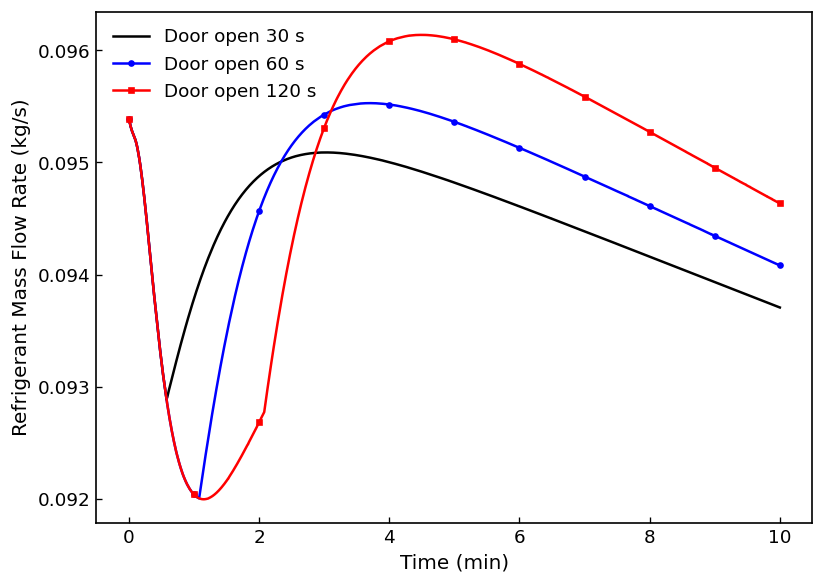

In [6]:
# Plot refrigerant mass flow rate over time
plt.figure(figsize=(7, 5))

# Slightly different marker spacing helps identify overlapping curves
colors = ["black", "blue", "red"]
markers = [None, "o", "s"]

for i, (case_name, file_path) in enumerate(door_cases.items()):
    df = pd.read_csv(file_path)

    # Keep time and refrigerant mass flow rate columns
    df = df[["time_s", "m_ref_kg_s"]]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()

    time_min = df["time_s"] / 60
    m_ref = df["m_ref_kg_s"]

    plt.plot(
        time_min,
        m_ref,
        linewidth=1.5,
        color=colors[i],
        marker=markers[i],
        markevery=300,
        markersize=3,
        label=case_name,
    )

# Academic-style formatting
plt.xlabel("Time (min)", fontsize=12)
plt.ylabel("Refrigerant Mass Flow Rate (kg/s)", fontsize=12)
plt.legend(frameon=False)
plt.tick_params(direction="in")
plt.tight_layout()

plt.show()

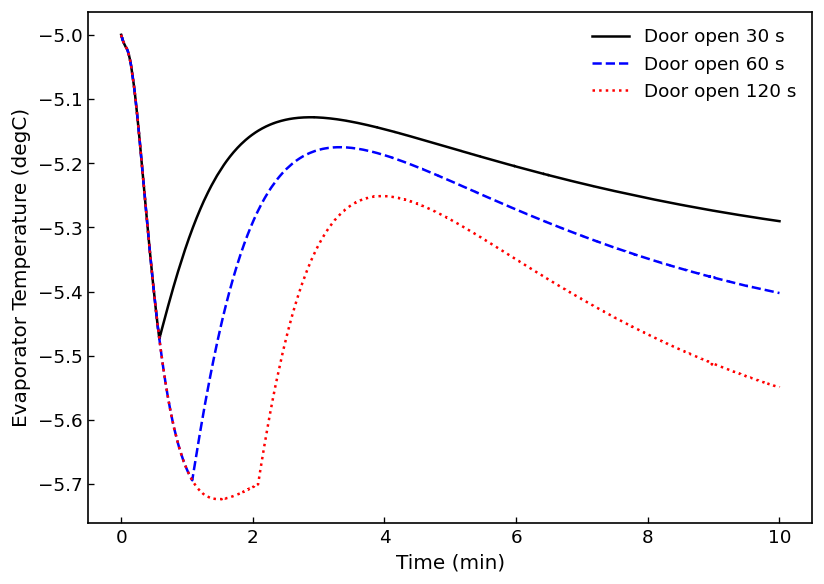

In [7]:
# Plot evaporator temperature over time
plt.figure(figsize=(7, 5))

# Define distinct colors and line styles for each door-open duration
colors = ["black", "blue", "red"]
line_styles = ["-", "--", ":"]

for i, (case_name, file_path) in enumerate(door_cases.items()):
    df = pd.read_csv(file_path)

    # Keep time and evaporator temperature columns
    df = df[["time_s", "tevap_c"]]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()

    time_min = df["time_s"] / 60
    evaporator_temp = df["tevap_c"]

    plt.plot(
        time_min,
        evaporator_temp,
        linewidth=1.5,
        linestyle=line_styles[i],
        color=colors[i],
        label=case_name,
    )

# Academic-style formatting
plt.xlabel("Time (min)", fontsize=12)
plt.ylabel("Evaporator Temperature (degC)", fontsize=12)
plt.legend(frameon=False)
plt.tick_params(direction="in")
plt.tight_layout()

plt.show()

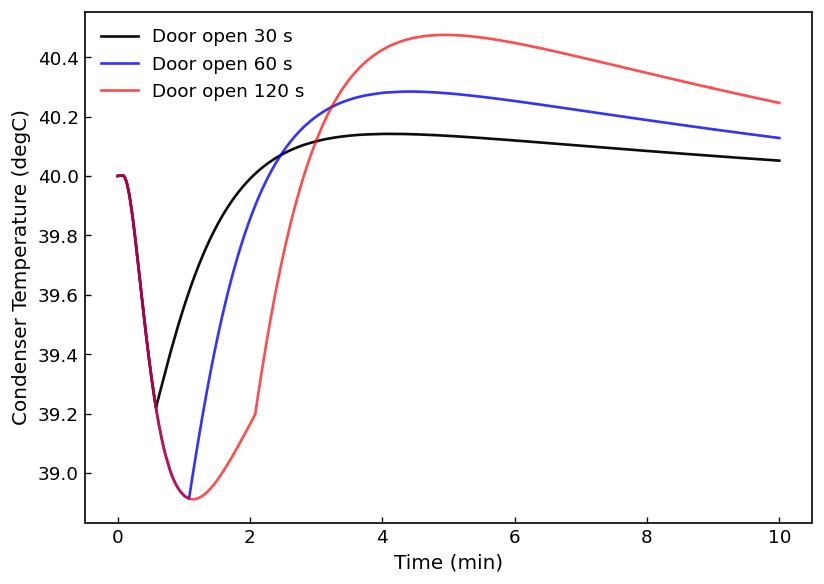

In [8]:
# Plot condenser temperature over time
plt.figure(figsize=(7, 5))

# Keep the same case colors and vary transparency for clearer overlap
colors = ["black", "blue", "red"]
alpha_values = [0.95, 0.80, 0.70]

for i, (case_name, file_path) in enumerate(door_cases.items()):
    df = pd.read_csv(file_path)

    # Keep time and condenser temperature columns
    df = df[["time_s", "tcond_c"]]
    df = df.apply(pd.to_numeric, errors="coerce").dropna()

    time_min = df["time_s"] / 60
    condenser_temp = df["tcond_c"]

    plt.plot(
        time_min,
        condenser_temp,
        linewidth=1.6,
        color=colors[i],
        alpha=alpha_values[i],
        label=case_name,
    )

# Academic-style formatting
plt.xlabel("Time (min)", fontsize=12)
plt.ylabel("Condenser Temperature (degC)", fontsize=12)
plt.legend(frameon=False)
plt.tick_params(direction="in")
plt.tight_layout()

plt.show()